# Simulation — building a signal whose answer you already know

Every other tutorial fits a model to data and asks whether the result looks right.
This one starts from the other end: it **builds** a continuous EEG signal out of
components you choose, so that afterwards you can check the estimate against the
number you put in.

That is the whole point of `trflearn.simulation`. A real recording never tells you
what its true response was, so an estimator can only be validated on a signal whose
answer is known in advance.

The round trip has five steps, and this notebook is one per section:

| | |
|---|---|
| **1** | design an experiment — event types, how often they occur |
| **2** | define the true kernels — the response each event type causes |
| **3** | convolve them into a continuous signal and bury it in noise |
| **4** | hand the result to TRFlearn as if it were a recording |
| **5** | compare what came back against what went in |

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt

from trflearn import TRFData, TRFModel
from trflearn.simulation import (
    ExperimentDesign, EEGSimulator, CompoundKernel, build_uniform_isi_sampler,
)

SR       = 256                  # Hz
DURATION = 2000                 # s
WINDOW   = (-0.1, 0.5)          # delay window for the TRF (s)
SEED     = 0

print(f"{DURATION} s at {SR} Hz  ->  {DURATION * SR:,} samples")

2000 s at 256 Hz  ->  512,000 samples


## 1 · An experiment design

`ExperimentDesign` describes *when things happen*, nothing about the response. Two
event types fire in an interleaved stream; `build_uniform_isi_sampler` draws the gap
between consecutive events uniformly from `[offset, offset + width)` samples — here
640 to 896, so 2.5 to 3.5 s apart.

That spacing is deliberate. It is comfortably longer than the 0.6 s delay window, so
consecutive responses barely overlap and this first tutorial stays easy.
**Tutorial 4** is the one that shortens the gap until responses collide, which is
where deconvolution stops being optional.

In [2]:
design = ExperimentDesign(
    n_events=200,
    event_types=["stimulus", "response"],
    sfreq=SR,
    duration_s=DURATION,
    isi_sampler=build_uniform_isi_sampler(
        width=256, offset=640, rng=np.random.default_rng(SEED)),
    seed=SEED,
)

events = design.generate_events()
events.head()

,type,latency,latency_s
0,stimulus,858,3.351562
1,response,1661,6.488281
2,stimulus,2432,9.500000
3,response,3141,12.269531
4,stimulus,3860,15.078125


`generate_events` gives the event table; `generate_features` turns it into what a model
actually consumes — one **impulse train per event type**, a column of zeros with a 1 at
each occurrence. That is the design matrix before any lagging.

In [3]:
features = design.generate_features()

for name, arr in features.items():
    print(f"{name:>10}: shape {arr.shape}, {int(arr.sum())} impulses")

  stimulus: shape (512000, 1), 100 impulses
  response: shape (512000, 1), 100 impulses


## 2 · Ground-truth kernels

A `CompoundKernel` is a sum of Gaussian bumps, each with a latency, an amplitude and a
width — a stand-in for the ERP components an event evokes. **These numbers are the
answer.** Everything after this point is an attempt to get them back.

`stimulus` gets two components (a positive one at 100 ms, a negative one at 200 ms);
`response` gets a single early positive bump at 50 ms.

In [4]:
stim_kernel = CompoundKernel("stimulus", sfreq=SR)
stim_kernel.add(peak_latency=0.10, amplitude=5.0, width=0.03)
stim_kernel.add(peak_latency=0.20, amplitude=-3.0, width=0.05)

resp_kernel = CompoundKernel("response", sfreq=SR)
resp_kernel.add(peak_latency=0.05, amplitude=4.0, width=0.02)

TRUTH = {"stimulus": stim_kernel, "response": resp_kernel}
for name, k in TRUTH.items():
    peaks = ", ".join(f"{c.peak_latency*1e3:.0f} ms ({c.amplitude:+.1f})"
                      for c in k.components)
    print(f"{name:>10}: {peaks}")

  stimulus: 100 ms (+5.0), 200 ms (-3.0)
  response: 50 ms (+4.0)


## 3 · Simulating the EEG

`EEGSimulator` convolves each kernel with the impulse train of the events it responds
to and sums the result. The `activation` callable is what ties a kernel to its rows of
the event table.

Then `add_noise` buries it. **Pink noise, not white** — real EEG has far more power at
low frequencies, and white noise would make the problem unrealistically easy exactly in
the band where TRFs live.

In [5]:
simulator = EEGSimulator(sfreq=SR, duration=DURATION)
simulator.add_kernel(stim_kernel, activation=lambda row: row["type"] == "stimulus")
simulator.add_kernel(resp_kernel, activation=lambda row: row["type"] == "response")

simulator.set_events(events)
# .copy() matters: `simulate()` hands back the simulator's own buffer, and `add_noise`
# mutates it in place -- without the copy, "clean" and "noisy" are the same array.
y_clean = simulator.simulate().copy()
simulator.add_noise(colour="pink", scale=0.5, rng=np.random.default_rng(SEED))
y = simulator.data

noise = y - y_clean
print(f"signal sd {y_clean.std():.3f} | noise sd {noise.std():.3f} | "
      f"SNR {y_clean.std() / noise.std():.2f}")

signal sd 0.335 | noise sd 0.500 | SNR 0.67


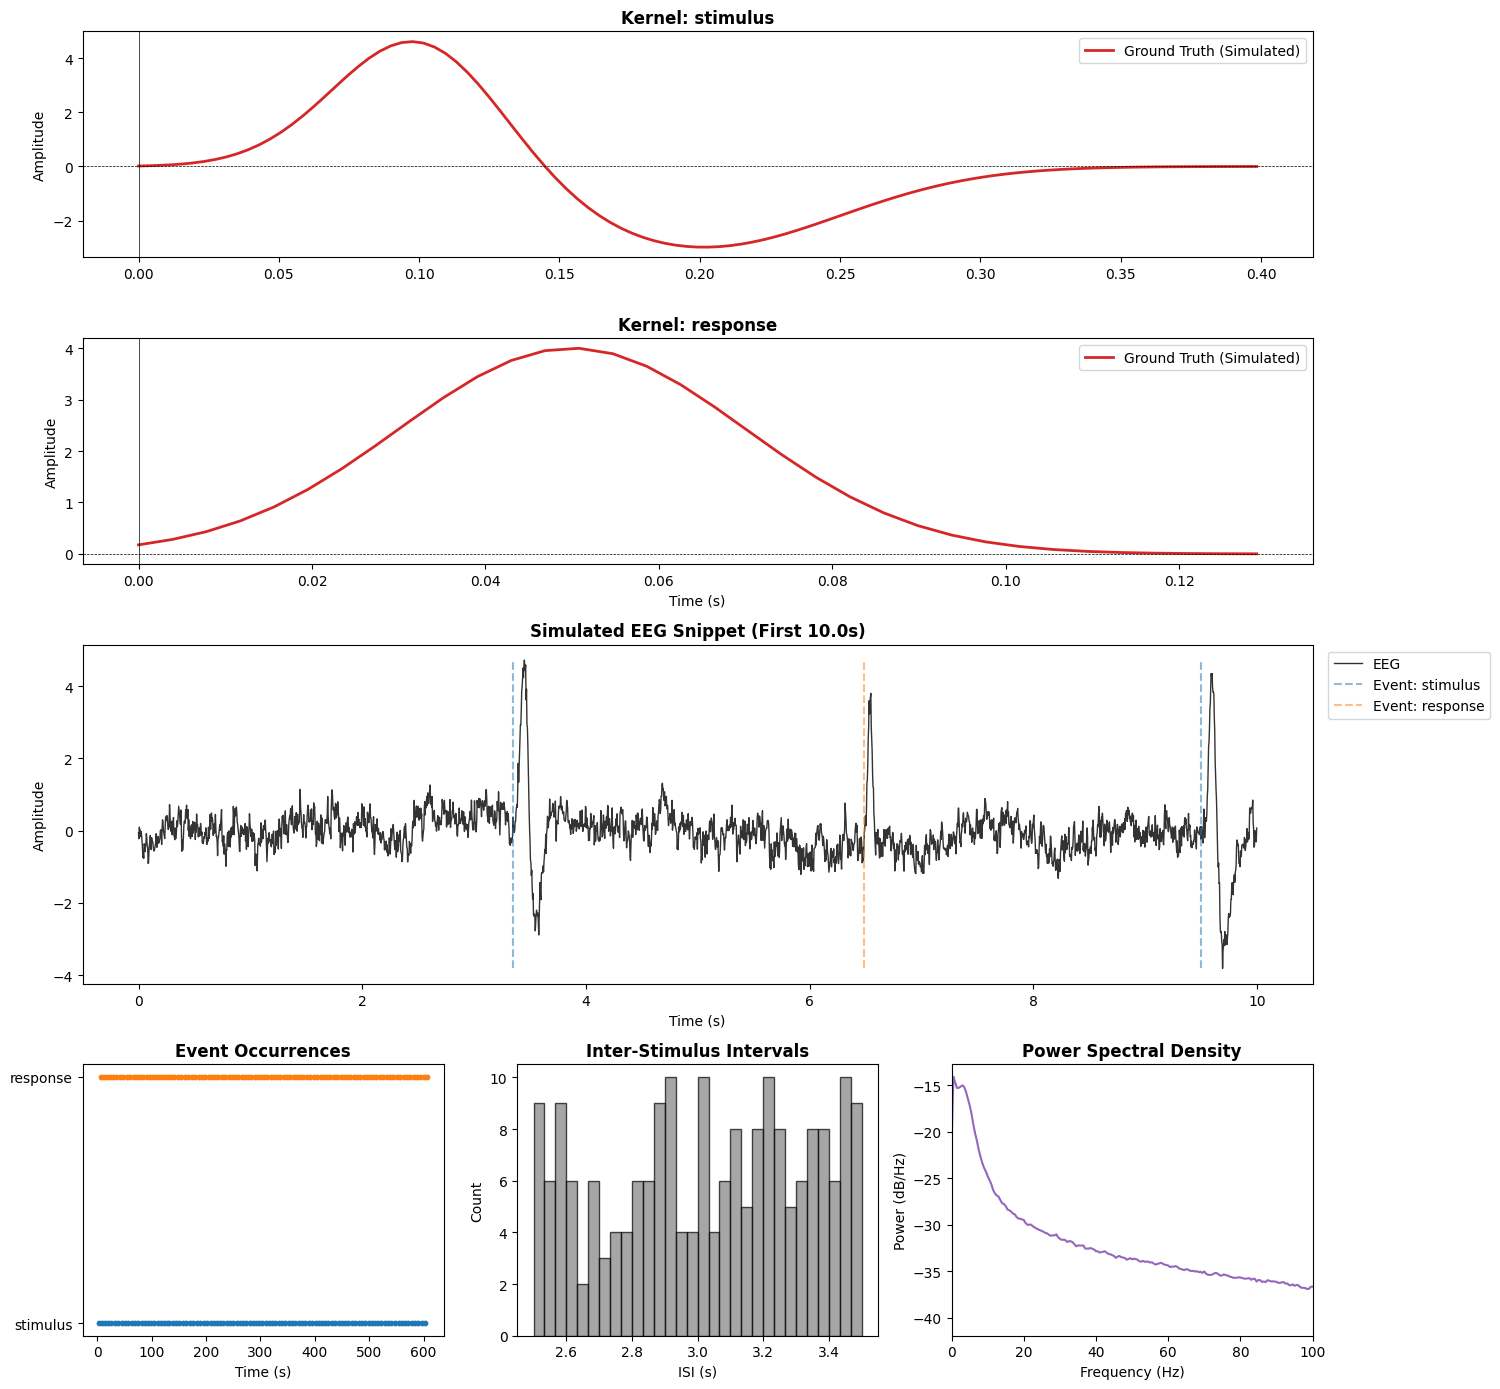

In [6]:
simulator.plot_simulation_kernels(show=True);

## 4 · Handing it to TRFlearn

From here nothing knows this signal was simulated. The container takes the impulse
trains as named features and the noisy signal as the target, exactly as it would take
a speech envelope and a real recording.

Two things worth copying into your own code:

- **`TRFData` is window-agnostic.** It never sees `WINDOW`; the delay window belongs to
  the model. One container can feed several models with different windows.
- **Naming the channel** (`target_names`) and attaching a montage costs one line and
  unlocks the `Evoked` export used in section 5, plus every topographic plot. With a
  single simulated channel the topography is meaningless, but the habit is the right
  one — on a real cohort the montage is also what gives
  `TRFGroup.tfce` its spatial adjacency.

In [7]:
data = TRFData(
    features=features,            # {"stimulus": (T, 1), "response": (T, 1)}
    y=y,                          # (T, 1)
    sample_rate=SR,
    target_names=["Cz"],
)
data.set_montage("standard_1005")
data.create_partitions(n_folds=5)

model = TRFModel(
    TRFDataset=data,
    features=["stimulus", "response"],
    default_window=WINDOW,
    feature_preprocess="Standardize",
    target_preprocess="Standardize",
    solver="ridge",
)
model.fit(regularization=0.01)
print("fitted:", {name: tuple(c.shape) for name, c in model.coef_.items()},
      "  (channels, sub-features, delays)")

fitted: {'stimulus': (1, 1, 155), 'response': (1, 1, 155)}   (channels, sub-features, delays)


## 5 · Recovered against the truth

The simulator's `truth` holds the kernels it injected, and draws them with the very
figure a fitted model draws — so each pair below reads side by side: the injected
kernel, then the one the model recovered. The quantitative check follows:
`to_evoked()` returns the fitted kernel as an MNE `Evoked` — that is the public way to
get at the delays and amplitudes — and the peak latency of each recovered component is
compared with the latency that was injected in section 2.

Recovered amplitudes are *not* expected to match the injected ones: the features and
the target were both standardized before fitting, and ridge shrinks coefficients toward
zero — which is why the two figures of a pair carry different units. **Latency is the
quantity that has to survive**, and it is what the comparison below checks.

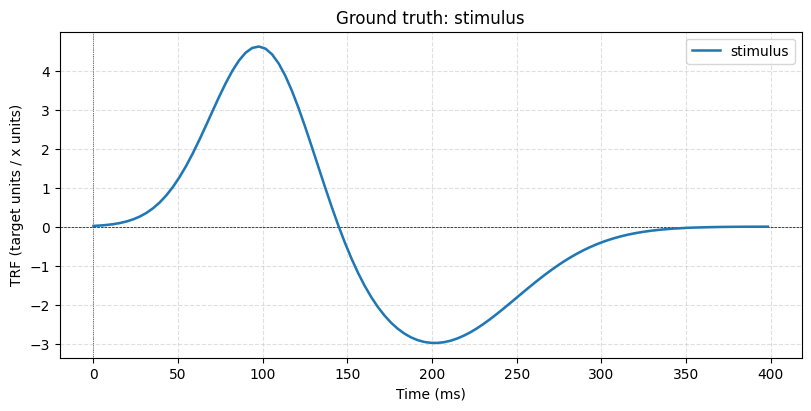

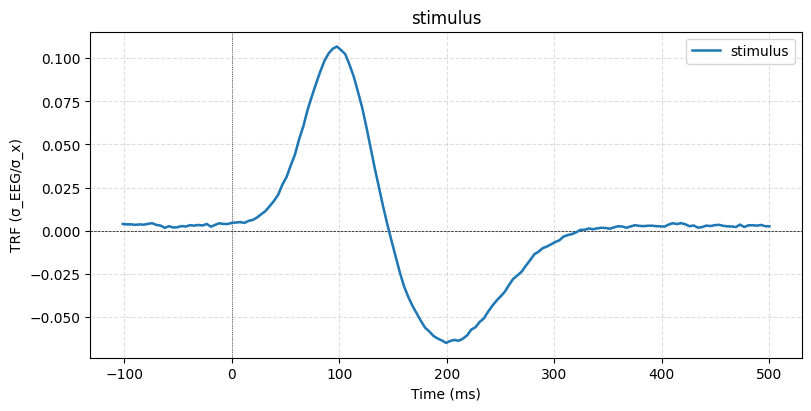

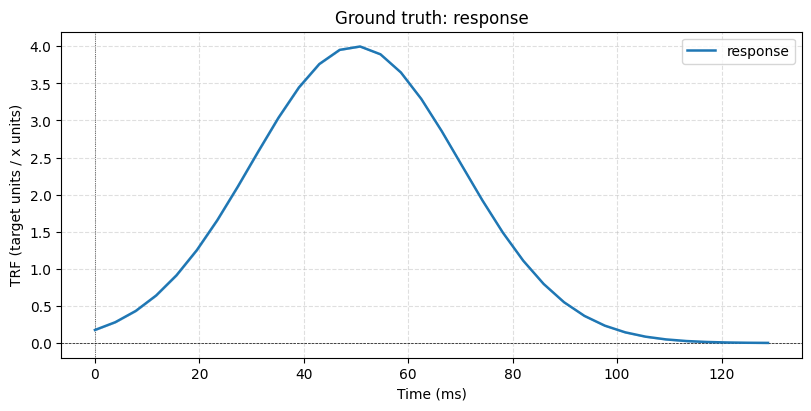

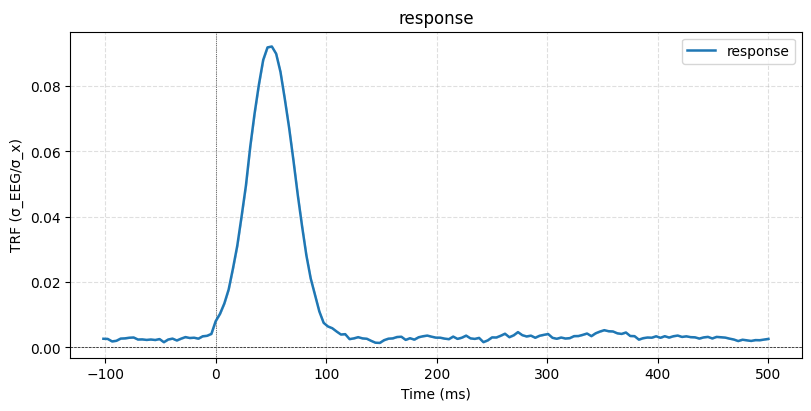

In [8]:
for name in ["stimulus", "response"]:
    simulator.truth.plot_average(name, style="native", show=True)
    model.plot_average(name, style="native", show=True)

In [9]:
evoked = model.to_evoked()

print(f"{'feature':>10}  {'injected':>9}  {'recovered':>10}  {'error':>7}")
for name, kernel in TRUTH.items():
    ev = evoked[name]
    times, wave = ev.times, ev.data.mean(axis=0)
    for comp in kernel.components:
        injected = comp.peak_latency
        # search near the injected latency, and follow the sign of the component
        window = (times > injected - 0.06) & (times < injected + 0.06)
        signed = wave * np.sign(comp.amplitude)
        found = times[window][np.argmax(signed[window])]
        print(f"{name:>10}  {injected*1e3:8.0f} ms  {found*1e3:9.0f} ms  "
              f"{(found - injected)*1e3:+6.0f} ms")

   feature   injected   recovered    error
  stimulus       100 ms         98 ms      -2 ms
  stimulus       200 ms        199 ms      -1 ms
  response        50 ms         51 ms      +1 ms


## Where this goes next

The round trip closes: kernels went in, the same latencies came back out of a signal
that was mostly noise. That is the only kind of evidence that tells you an estimator
works, and it is available exclusively on simulated data.

- **[2 · Auditory pipeline](../02_auditory_pipeline/)** repeats this check on a
  realistic auditory TRF and uses it to *measure* the three cross-validation paradigms
  against each other, instead of asserting which is better.
- **[3 · Categorical events](../03_categorical_events/)** stays with discrete events
  and goes deeper into event-related designs.
- **[4 · Overlap deconvolution](../04_overlap_deconvolution/)** shortens the gap
  between events until epoch-and-average breaks and only deconvolution survives.